# Project 2: Sleep & its effects

This project is mainly looking at how sleep would effect the productivity of people. Essentially what I'll be doing here is that I'll look at how sleep quality was recorded and essentially see if its more likely for someone who has a certian category to get better sleep. 


In [1]:
!pip install scikit-learn
!pip install pandas
!pip install seaborn
!pip install matplotlib

## Preprocessing

Right now all we are doing is getting the data set ready for use

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

In [6]:
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


First lets see if theres anything that is null

In [8]:
df.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

While most categories have no nulls, sleep disorder does seem to have some nulls. While there are nulls present, I don't believe we can drop the column. For now lets just see how many bins each value has

In [10]:
for col in df.columns:
    print(f"{col}:\n {df[col].value_counts()}\n")

Person ID:
 Person ID
374    1
1      1
2      1
3      1
4      1
      ..
11     1
10     1
9      1
8      1
7      1
Name: count, Length: 374, dtype: int64

Gender:
 Gender
Male      189
Female    185
Name: count, dtype: int64

Age:
 Age
43    34
44    30
37    20
38    20
50    20
31    18
32    17
53    17
59    16
39    15
45    14
33    13
29    13
30    13
36    12
35    12
41    12
49    11
42     9
57     9
52     9
51     8
54     7
58     6
28     5
40     4
48     3
55     2
34     2
56     2
27     1
Name: count, dtype: int64

Occupation:
 Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

Sleep Duration:
 Sleep Duration
7.2    36
6.0    31
7.8    28
6.5    26
6.1    25
7.7    24
6.6    20
7.

overall, it seems like most categories have a good amount of bins. I'd like to talk about the sleep disorder category again as it seems that there are 3 seperate values it could be (Sleep Apnea, Insomina, and null/no disorder). another thing to note is that sleep quality seems left skewed. for now I will be changing sleep quality into a true or false category with the baseline of 5.

In [12]:
df.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

In [13]:
def sleepQual(i):
    if(i/5 > 1):
        return True
    return False

In [14]:
sleepQual(5)

False

In [15]:
sleepQual(6)

True

In [16]:
sq_df = df
sq_df['SleepWell'] = df['Quality of Sleep'].apply(sleepQual)

In [17]:
sq_df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,SleepWell
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,True
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,True
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,True
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,False
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,True
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,True
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,True
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,True


In [18]:
sq_df.drop(columns = ['Quality of Sleep'])

,Person ID,Gender,Age,Occupation,Sleep Duration,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,SleepWell
0,1,Male,27,Software Engineer,6.1,42,6,Overweight,126/83,77,4200,NaN,True
1,2,Male,28,Doctor,6.2,60,8,Normal,125/80,75,10000,NaN,True
2,3,Male,28,Doctor,6.2,60,8,Normal,125/80,75,10000,NaN,True
3,4,Male,28,Sales Representative,5.9,30,8,Obese,140/90,85,3000,Sleep Apnea,False
4,5,Male,28,Sales Representative,5.9,30,8,Obese,140/90,85,3000,Sleep Apnea,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,75,3,Overweight,140/95,68,7000,Sleep Apnea,True
370,371,Female,59,Nurse,8.0,75,3,Overweight,140/95,68,7000,Sleep Apnea,True
371,372,Female,59,Nurse,8.1,75,3,Overweight,140/95,68,7000,Sleep Apnea,True
372,373,Female,59,Nurse,8.1,75,3,Overweight,140/95,68,7000,Sleep Apnea,True


In [19]:
import seaborn as sns

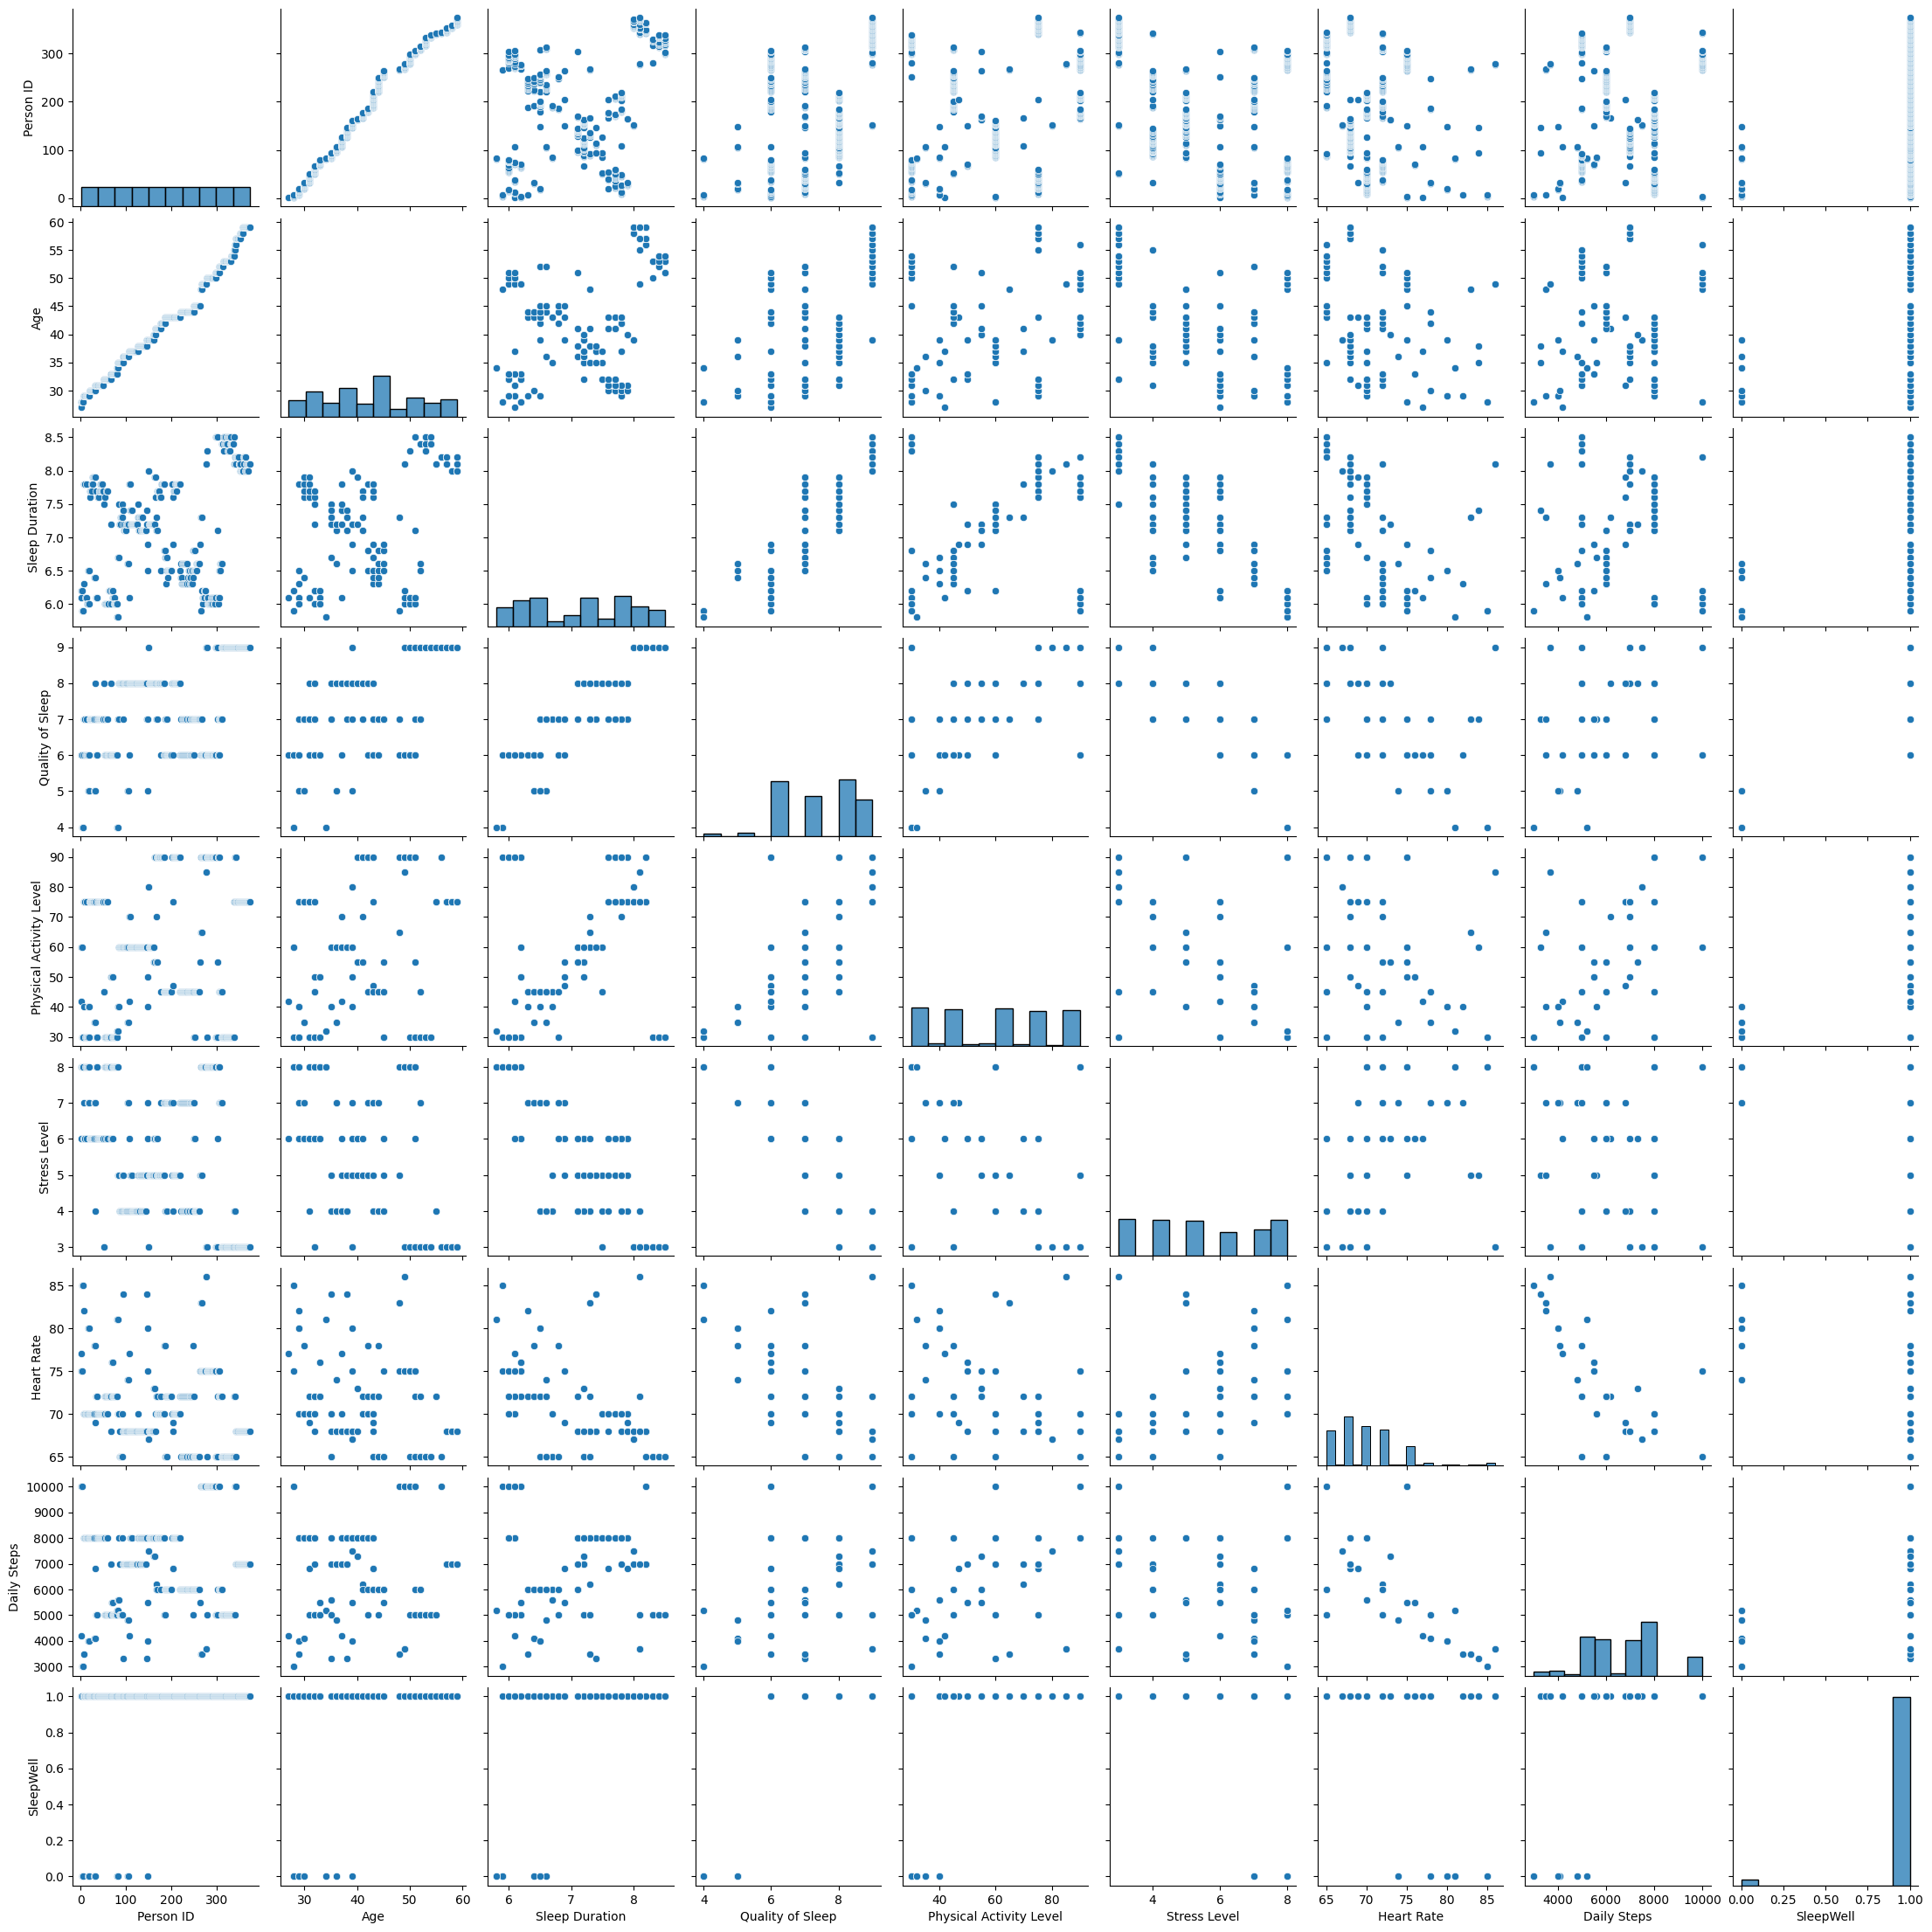

In [20]:
sns.pairplot(data = sq_df)

Now that we've gotten a variable that tracks if a person had a generally good sleep, we can now make predictions based on this. I could convert heart rate into a decimal form, however I don't see much use in doing that at the moment. For now, lets convert all of the categorical variables to dummies to prepare for modeling. I will also drop some categories as I see fit 

In [22]:
sq_df.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
SleepWell                     bool
dtype: object

In [23]:
sq_df = pd.get_dummies(sq_df, columns = ['Gender'])
sq_df = pd.get_dummies(sq_df, columns = ['Occupation'])
sq_df = pd.get_dummies(sq_df, columns = ['BMI Category'])
sq_df = pd.get_dummies(sq_df, columns = ['Sleep Disorder'])

In [24]:
sq_df

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Blood Pressure,Heart Rate,Daily Steps,SleepWell,...,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder_Insomnia,Sleep Disorder_Sleep Apnea
0,1,27,6.1,6,42,6,126/83,77,4200,True,...,False,False,True,False,False,False,False,True,False,False
1,2,28,6.2,6,60,8,125/80,75,10000,True,...,False,False,False,False,True,False,False,False,False,False
2,3,28,6.2,6,60,8,125/80,75,10000,True,...,False,False,False,False,True,False,False,False,False,False
3,4,28,5.9,4,30,8,140/90,85,3000,False,...,False,False,False,False,False,False,True,False,False,True
4,5,28,5.9,4,30,8,140/90,85,3000,False,...,False,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,59,8.1,9,75,3,140/95,68,7000,True,...,False,False,False,False,False,False,False,True,False,True
370,371,59,8.0,9,75,3,140/95,68,7000,True,...,False,False,False,False,False,False,False,True,False,True
371,372,59,8.1,9,75,3,140/95,68,7000,True,...,False,False,False,False,False,False,False,True,False,True
372,373,59,8.1,9,75,3,140/95,68,7000,True,...,False,False,False,False,False,False,False,True,False,True


In [25]:
sq_df.drop(columns = ['Blood Pressure'])

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,SleepWell,Gender_Female,...,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder_Insomnia,Sleep Disorder_Sleep Apnea
0,1,27,6.1,6,42,6,77,4200,True,False,...,False,False,True,False,False,False,False,True,False,False
1,2,28,6.2,6,60,8,75,10000,True,False,...,False,False,False,False,True,False,False,False,False,False
2,3,28,6.2,6,60,8,75,10000,True,False,...,False,False,False,False,True,False,False,False,False,False
3,4,28,5.9,4,30,8,85,3000,False,False,...,False,False,False,False,False,False,True,False,False,True
4,5,28,5.9,4,30,8,85,3000,False,False,...,False,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,59,8.1,9,75,3,68,7000,True,True,...,False,False,False,False,False,False,False,True,False,True
370,371,59,8.0,9,75,3,68,7000,True,True,...,False,False,False,False,False,False,False,True,False,True
371,372,59,8.1,9,75,3,68,7000,True,True,...,False,False,False,False,False,False,False,True,False,True
372,373,59,8.1,9,75,3,68,7000,True,True,...,False,False,False,False,False,False,False,True,False,True


In [26]:
sq_df.dtypes

Person ID                            int64
Age                                  int64
Sleep Duration                     float64
Quality of Sleep                     int64
Physical Activity Level              int64
Stress Level                         int64
Blood Pressure                      object
Heart Rate                           int64
Daily Steps                          int64
SleepWell                             bool
Gender_Female                         bool
Gender_Male                           bool
Occupation_Accountant                 bool
Occupation_Doctor                     bool
Occupation_Engineer                   bool
Occupation_Lawyer                     bool
Occupation_Manager                    bool
Occupation_Nurse                      bool
Occupation_Sales Representative       bool
Occupation_Salesperson                bool
Occupation_Scientist                  bool
Occupation_Software Engineer          bool
Occupation_Teacher                    bool
BMI Categor

## Training

Since we're trying to figure out the relationship between sleep quality & all the other factors, lets split the dataset accordingly

In [303]:
x = sq_df.drop(columns = ['SleepWell','Blood Pressure','Quality of Sleep'])
y = sq_df['SleepWell']

In [305]:
from sklearn.model_selection import train_test_split

In [307]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size = 0.3) 
#doing .5 as part of the rough draft, however may adjust differently for the final model

In [309]:
print("x_train", x_train.shape)
print("x_test", x_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

x_train (261, 26)
x_test (113, 26)
y_train (261,)
y_test (113,)


Lets actually train the model now

In [312]:
from sklearn import tree

In [314]:
clf = tree.DecisionTreeClassifier()

In [316]:
clf = clf.fit(x_train, y_train)

And our model is trained

# Evaluation


Here we'll make sure our model is accurate 

In [321]:
predicted = clf.predict(x_test)

In [323]:
predicted

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

Since we're trying to see if someone slept well, these results are to be expected since it is split between true & false

In [326]:
clf.score(x_test, y_test)

0.9911504424778761

the score is quite high which does signify a higher accuracy, however this isn't necessairly the best thing.

Despite this since we decided to use a tree model, we can actually see which categories are more prioritized by the model itself

In [329]:
import matplotlib.pyplot as plt

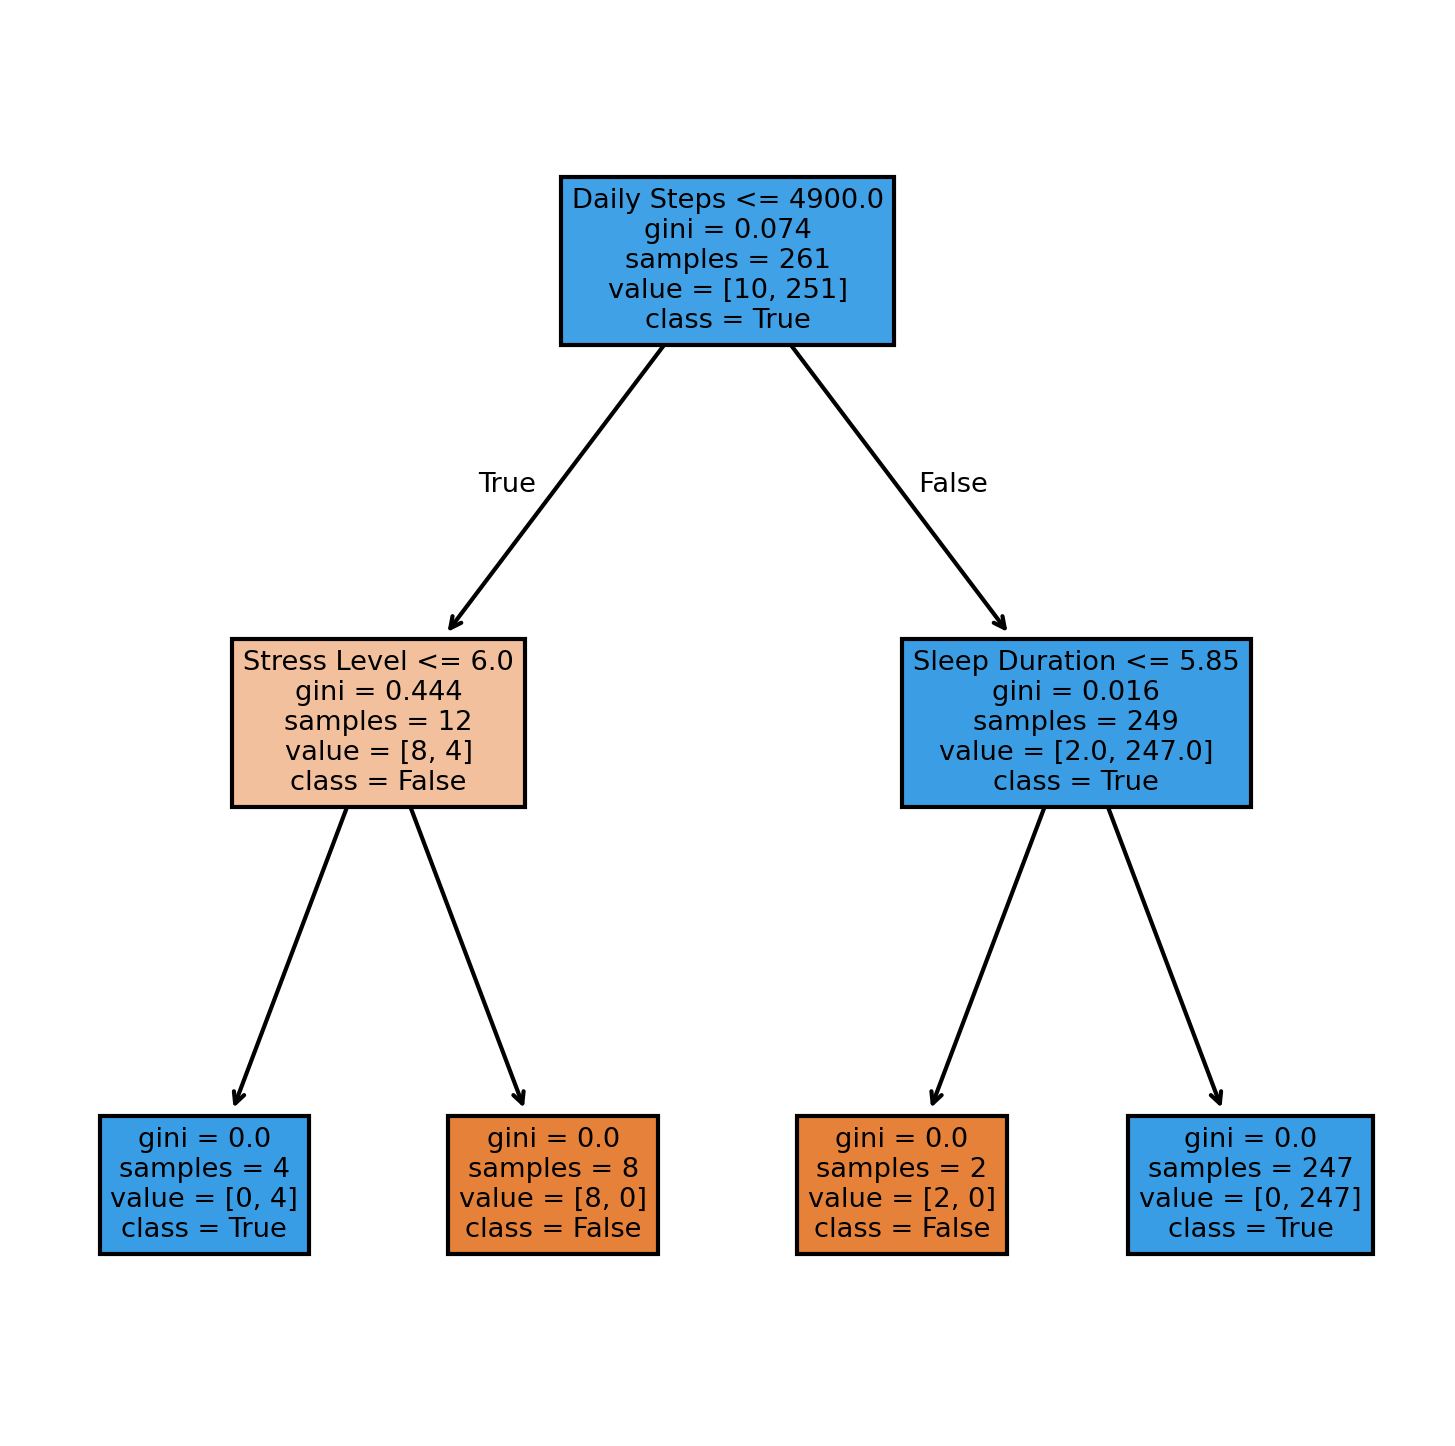

In [331]:
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (6,6), dpi=300)
tree.plot_tree(clf, max_depth = 4, feature_names = x.columns, class_names = {0: "False", 1:"True"}, filled=True)
plt.show()

Interestingly enough, the model prioritized Daily steps over anything else followed up by stress & sleep

Most samples had less than 4900 steps so in that case they checked if someone had more than 5.85 hours of sleep to determine if they slept well or not.
for the 12 samples that did actually have more than 4900 steps they checked if their stress level was less than 6.0 and if so they also ended up having good sleep.

We shall visualize this so we can see the importance of other given categories

In [337]:
fi = clf.feature_importances_ 
fi = pd.Series(data = fi, index = x.columns) 
fi.sort_values(ascending=False, inplace=True)

C:\Users\aadim\AppData\Local\Temp\ipykernel_12564\398375841.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


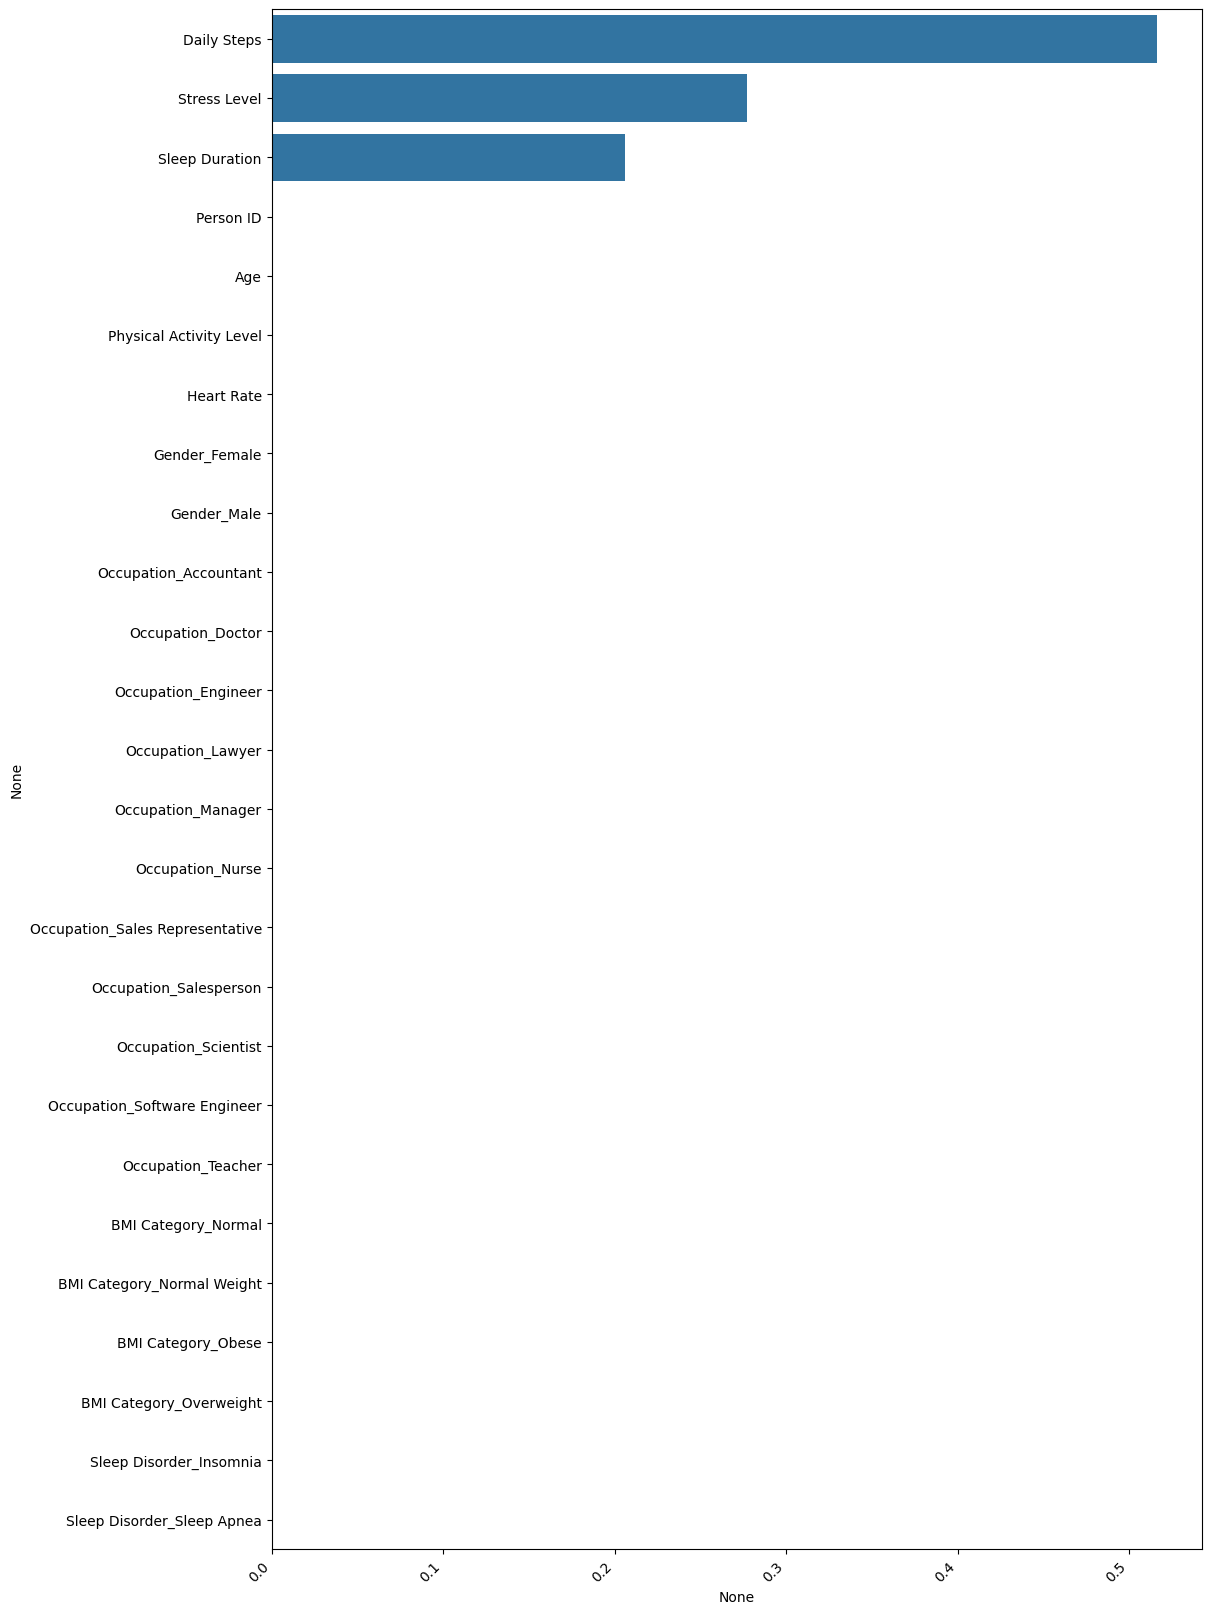

In [346]:
plt.figure(figsize=(12, 20))
chart = sns.barplot(x=fi, y=fi.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

It seems to ONLY factor in those 3 categories which does make some sense, however I do believe that there may be more too it

I'd like to finish this by running a classification report

In [354]:
from sklearn import metrics

In [356]:
p = clf.predict(x_test)

In [358]:
print(metrics.classification_report(y_test, predicted))

              precision    recall  f1-score   support

       False       0.67      1.00      0.80         2
        True       1.00      0.99      1.00       111

    accuracy                           0.99       113
   macro avg       0.83      1.00      0.90       113
weighted avg       0.99      0.99      0.99       113



Most things appear to be high and given the nature of our data set that does make sense.

surprisingly false seems to have a precision significantly lower than the other categories, however I do not believe this to be much of an issue